# NBA MVP — Causal Effect of PER on Vote Share

**Course:** Foundations of Data Science

**Group Members:** Tyler Song, Hyeonung Cho

## 1. Introduction

### 1.1. The Question / Estimand

**What is the causal effect of a player's Player Efficiency Rating (PER) on his MVP vote share, among players who received any MVP votes in a given NBA season (1980–present)?**

The estimand is $\beta_P$: the slope of standardized PER on the log-odds of vote share interpreted as the change in expected vote share associated with a one-standard-deviation increase in PER, holding Usage Rate fixed.

### 1.2. Data Description

- **Source:** [Sumitro Datta — *NBA, ABA, BAA Stats*](https://www.kaggle.com/datasets/sumitrodatta/nba-aba-baa-stats) on Kaggle.
- **Files used:** `Advanced.csv` (PER, Usage Rate, season-by-player rows) and `Player Award Shares.csv` (MVP vote share per player-season).
- **Rows:** one row per (player, season) combination.
- **Columns used:** `player_id`, `season`, `team`, `per`, `usg_percent`, `share` (renamed `mvp_share`).
- **Filtering:** restricted to NBA seasons from 1980 onward (3-point era), and to players who received at least one MVP vote (`mvp_share > 0`). For mid-season trades, the season-total row (`2TM`/`3TM`/etc.) is used so PER and Usage reflect the full season MVP voters considered.
- **Why this dataset:** The database is sourced from Basketball Reference, which is widely used by analysts. It contains both the candidate treatment (PER) and the candidate confounder (Usage Rate) at the season level.

## 2. Causal Model

```
   PER ──────────► MVP share
    ▲                 ▲
    │                 │
    └─── Usage Rate ──┘
```

### 2.1. Variables

* **PER (Treatment):** Player Efficiency Rating: Hollinger's box-score-based composite metric, league-mean-adjusted to ~15 each season. Higher PER reflects per-minute production efficiency.
* **MVP share (Outcome):** Fraction of total MVP votes received in a season; bounded in $(0, 1)$
* **USG (Confound):** Usage Rate: estimated percentage of team possessions a player ends while on the floor (shots, free throw attempts, turnovers). Captures shot-creation responsibility independent of efficiency.

### 2.2. Assumed Causal Relationships

- **PER → MVP share.** The relationship of interest. Voters reward statistical dominance, and PER summarizes box-score performance.
- **USG → MVP share.** High-volume players are more visible (the team relies on them) and accumulate counting stats voters cite, independent of efficiency. We expect a positive but weaker effect than PER.
- **USG → PER.** This is the key adjustment-set rationale. As a player's role expands (USG rises), they take harder shots and attract more defensive attention, often *reducing* per-possession efficiency (the "skill curve"). So Usage exerts a real causal influence on PER in addition to its direct influence on MVP voting.

Conditioning on USG blocks the back-door path $\text{PER} \leftarrow \text{USG} \rightarrow \text{MVP share}$, leaving the coefficient on PER as the direct effect of efficiency on vote share at fixed opportunity. We acknowledge that PER and USG are likely *jointly determined* in practice (skill drives touches, touches affect efficiency), so the estimate is best read as the partial association of PER with vote share at fixed Usage rather than a fully identified causal effect.

## 3. Statistical Model

The outcome `mvp_share` lies in $(0, 1)$, except for one season (shoutout Curry!), so a **Beta likelihood** with a logit link on the mean is the natural choice. Predictors are standardized ($z$-scored) so prior scales are interpretable as effects per standard deviation.

$$y_i \sim \text{Beta}(\mu_i \phi,\, (1 - \mu_i)\phi)$$
$$\text{logit}(\mu_i) = \alpha + \beta_P \cdot \text{PER}_i^z + \beta_U \cdot \text{USG}_i^z$$
$$\alpha \sim \mathcal{N}(-2,\, 1)\qquad \beta_P \sim \mathcal{N}(0.5,\, 1)\qquad \beta_U \sim \mathcal{N}(0.3,\, 1)\qquad \phi \sim \text{Exponential}(0.1)$$

### 3.1. Justification of Priors

- **$\alpha \sim \mathcal{N}(-2, 1)$.** The mean MVP share among vote-getters is ~0.16, so $\text{logit}(0.16) \approx -1.7$. Centering the intercept prior near this value places mass over realistic baseline shares (95% prior interval ≈ $[0.018, 0.5]$ on the share scale) without forcing a specific value.
- **$\beta_P \sim \mathcal{N}(0.5, 1)$.** Domain knowledge says higher efficiency drives more MVP votes — the relationship is unambiguously positive. We encode this with a prior centered at $+0.5$ (a moderate positive effect on the standardized scale) but with SD 1 wide enough to allow effects up to ~2.5 or back to mildly negative if the data demand it.
- **$\beta_U \sim \mathcal{N}(0.3, 1)$.** Usage Rate also signals a positive relationship — high-usage players are more visible and accumulate counting stats — but the effect should be weaker than PER's after we condition on efficiency, since much of the "volume drives votes" signal is already encoded in PER. We center at $+0.3$ to reflect this weaker positive belief, with the same SD of 1.
- **$\phi \sim \text{Exponential}(0.1)$.** The exponential rate of 0.1 has mean 10 and is heavy-tailed enough that small concentration values (consistent with noisy outcomes — narrative, voter fatigue) are also plausible. We avoid `Exponential(1)` because it concentrates $\phi$ near 1, where the Beta distribution becomes near-uniform / U-shaped.

The prior predictive simulation below confirms these priors imply realistic vote-share distributions before any data is observed.

### 3.2. Justification of Outcome Distribution

`mvp_share` is a continuous proportion strictly in $(0, 1)$ with a heavy right skew (median 0.022, max 0.998). The **Beta distribution** is supported on $(0, 1)$ and can flex from heavily right-skewed to symmetric to U-shaped via its two parameters, making it well-suited to the empirical shape. A Normal likelihood would assign nonzero probability to impossible vote shares (negative or > 1); a logistic-Normal alternative is viable but loses the Beta's natural mean–variance coupling, which is convenient for interpreting $\phi$.

### 3.3. Handling the Confound

Per the DAG (Section 2), Usage Rate has back-door arrows to both PER and MVP share. Including $\beta_U \cdot \text{USG}^z$ as a covariate in the linear predictor blocks the back-door path $\text{PER} \leftarrow \text{USG} \rightarrow \text{MVP share}$. Under the assumed DAG, $\beta_P$ then estimates the direct effect of PER on log-odds vote share at fixed Usage. The estimate is interpretable as a partial association — see Section 8.2 for caveats around joint determination.

### 3.4. First-Stage Hurdle (Binomial Gate)

The first stage is a logistic regression that predicts whether a player will receive any MVP votes:

$$P(\text{any votes}_i \mid \text{PER}_i, \text{USG}_i) = \sigma(\alpha_h + \beta_{P,h} \cdot \text{PER}_i + \beta_{U,h} \cdot \text{USG}_i)$$

A player whose predicted probability exceeds 0.5 is passed to the Beta regression; one who does not is assigned a combined predicted share of 0. The threshold is a decision rule, not a literal probability cut — it controls the recall-vs-precision trade-off of the gate (Section 5b).

**Class balancing.** Because vote-getters are heavily outnumbered (~3.5% of player-seasons), we fit with `class_weight="balanced"`, which up-weights the minority class so the gate optimizes for **recall** over raw accuracy. The cost is calibration — predicted probabilities are systematically inflated — but we care about the binary decision at threshold 0.5, not the literal probability.


In [1]:
# Prior predictive simulation: do these priors imply realistic vote-share distributions?
import numpy as np
import matplotlib.pyplot as plt
import pymc as pm
import arviz as az

N_SYNTH = 730  # match real-data sample size
rng = np.random.default_rng(42)
per_z_synth = rng.standard_normal(N_SYNTH)
usg_z_synth = rng.standard_normal(N_SYNTH)

with pm.Model() as prior_model:
    alpha  = pm.Normal("alpha", -2, 1)
    beta_P = pm.Normal("beta_P", 0.5, 1)
    beta_U = pm.Normal("beta_U", 0.3, 1)
    phi    = pm.Exponential("phi", 0.1)
    eta = alpha + beta_P * per_z_synth + beta_U * usg_z_synth
    mu = pm.math.sigmoid(eta)
    pm.Beta("y", alpha=mu * phi, beta=(1 - mu) * phi)
    prior_pred = pm.sample_prior_predictive(samples=200, random_seed=42)

prior_y = prior_pred.prior["y"].values.flatten()

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(prior_y, bins=50, density=True, color="steelblue", alpha=0.75, edgecolor="white")
ax.set(xlabel="simulated MVP vote share", ylabel="density", title="Prior predictive distribution of vote share")
fig.tight_layout()
plt.show()

ModuleNotFoundError: No module named 'pymc'

## 4. Model Validation on Simulated Data

Before fitting real data, we validate the procedure (prior + likelihood + sampler) on **simulated data with known parameter values**. We hold standardized predictors fixed (drawn from $\mathcal{N}(0, 1)$, $n = 730$, matching the real-data sample size) and generate `mvp_share` from the assumed Beta likelihood at chosen "true" values:

$$\alpha_\text{true} = -1.5,\quad \beta_{P,\text{true}} = 0.9,\quad \beta_{U,\text{true}} = 0.6,\quad \phi_\text{true} = 3$$

These values lie in the plausible region of the priors but are deliberately offset from the prior centers ($\beta_P$ truth is 0.4 above its prior mean of 0.5; $\beta_U$ truth is 0.3 above its prior mean of 0.3), so successful recovery requires the **data** (not the prior) to drive the posterior. We then fit the same model and check whether the 94% HDI for each parameter brackets its true value (red line).

Progress,Draws,Divergences,Step Size,Gradients/Draw
,2000,0,0.67,7
,2000,0,0.67,7
,2000,0,0.73,7
,2000,0,0.72,7


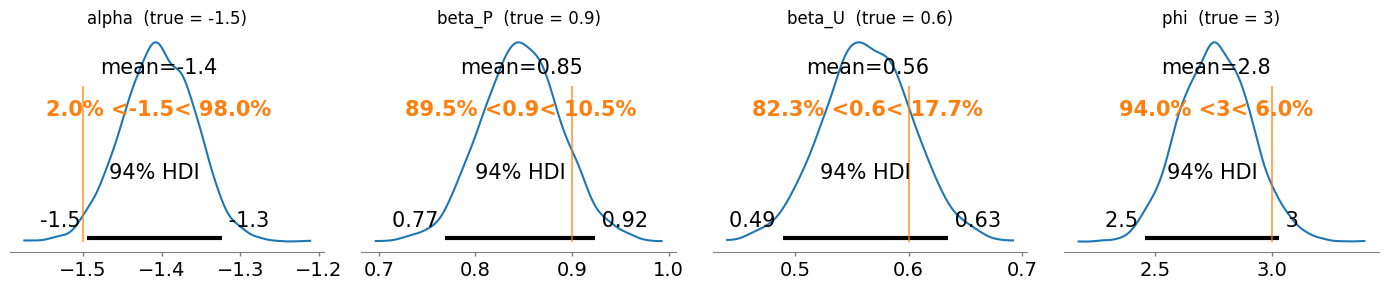

In [ ]:
# Define fixed parameter values
alpha_true, betaP_true, betaU_true, phi_true = -1.5, 0.9, 0.6, 3

# Simulate data using fixed values (predictors carried over from prior predictive cell)
eta_sim = alpha_true + betaP_true * per_z_synth + betaU_true * usg_z_synth
mu_sim = 1 / (1 + np.exp(-eta_sim))
y_sim = np.clip(
    rng.beta(mu_sim * phi_true, (1 - mu_sim) * phi_true),
    1e-6, 1 - 1e-6,
)

# Fit the same model on simulated data
with pm.Model() as sim_model:
    alpha  = pm.Normal("alpha", -2, 1)
    beta_P = pm.Normal("beta_P", 0.5, 1)
    beta_U = pm.Normal("beta_U", 0.3, 1)
    phi    = pm.Exponential("phi", 0.1)
    eta = alpha + beta_P * per_z_synth + beta_U * usg_z_synth
    mu = pm.math.sigmoid(eta)
    pm.Beta("y", alpha=mu * phi, beta=(1 - mu) * phi, observed=y_sim)
    idata_sim = pm.sample(1000, tune=1000, target_accept=0.9, chains=4, random_seed=42, nuts_sampler="nutpie")

# Compare posterior to true values
true_vals = {"alpha": alpha_true, "beta_P": betaP_true, "beta_U": betaU_true, "phi": phi_true}
fig, axes = plt.subplots(1, 4, figsize=(14, 3))
for ax, (name, true_val) in zip(axes, true_vals.items()):
    az.plot_posterior(idata_sim, var_names=name, ax=ax, ref_val=true_val)
    ax.set_title(f"{name}  (true = {true_val})")
plt.tight_layout()
plt.show()

**Recovery result.** The 94% HDIs bracket the true values for all four parameters. The procedure can identify the assumed parameters from data of this size and noise level, supporting the use of the same model on real data.

We additionally observed (sensitivity check, not shown) that under heavier outcome noise ($\phi = 1$) the slope coefficients are attenuated toward their prior centers by ~0.1–0.2. This is a useful prior–likelihood interplay diagnostic: when the data signal weakens, the prior dominates. At realistic noise levels ($\phi \approx 3$, near the real-data posterior), recovery is clean.

## 5. Data Preparation (Real Data)

We load `Advanced.csv` (PER, Usage Rate) and `Player Award Shares.csv` (MVP vote share), restrict to NBA seasons from 1980 onward, and keep only player-seasons with `mvp_share > 0`. For mid-season trades, the season-total row (`2TM`/`3TM`/etc.) is preferred so PER and Usage reflect the full season. Predictors are then standardized to $z$-scores so prior scales are interpretable per standard deviation.

Players with `mvp_share = 1.0` (e.g. Stephen Curry's unanimous 2016 MVP) fall on the boundary of the Beta likelihood's open $(0, 1)$ support, where the log-density is undefined. We retain these rows by clipping the share to $1 - 10^{-3} = 0.999$ — a numerically negligible adjustment that preserves the rare unanimous-MVP signal in the dataset.

In [ ]:
import pandas as pd
from pathlib import Path

DATA_RAW = Path("data") / "raw"
SEASON_MIN = 1980  # 3-point era onward

# Load Advanced stats
adv = pd.read_csv(DATA_RAW / "Advanced.csv")
adv = adv[adv["lg"] == "NBA"].copy()
# Keep season-total rows for traded players ("2TM", "3TM", ...) or single-team rows
is_total = adv["team"].str.match(r"^\dTM$", na=False)
counts = adv.groupby(["player_id", "season"])["player_id"].transform("size")
adv = adv[(counts == 1) | is_total]
adv = adv[["player_id", "player", "season", "team", "g", "mp", "per", "usg_percent"]]

# Load MVP vote shares
mvp = pd.read_csv(DATA_RAW / "Player Award Shares.csv")
mvp = mvp[mvp["award"].str.lower() == "nba mvp"].copy()
mvp = mvp[["player_id", "season", "player", "share", "winner"]].rename(
    columns={"share": "mvp_share"}
)

# Merge, filter to vote-getters in 1980+
df = mvp.merge(adv.drop(columns=["player"]), on=["player_id", "season"], how="inner")
df = df[df["season"] >= SEASON_MIN]
df = df.dropna(subset=["per", "usg_percent", "mvp_share"])
df = df[(df["mvp_share"] > 0) & (df["mvp_share"] <= 1)].copy()
# Beta likelihood is undefined at y=1; nudge unanimous MVPs (Curry 2016) inward
df["mvp_share"] = df["mvp_share"].clip(upper=1 - 1e-3)
df = df.sort_values(["season", "mvp_share"], ascending=[True, False]).reset_index(drop=True)

# Standardize predictors
for col in ("per", "usg_percent"):
    df[f"{col}_z"] = (df[col] - df[col].mean()) / df[col].std()

print(f"Built {len(df):,} rows ({df['season'].min()}–{df['season'].max()}), "
      f"{df['player_id'].nunique()} unique players, "
      f"{df['winner'].sum()} MVP winners.")
df[["per", "usg_percent", "mvp_share"]].describe().round(3)

Built 731 rows (1980–2025), 209 unique players, 46 MVP winners.


,per,usg_percent,mvp_share
count,731.000,731.000,731.000
mean,22.737,26.925,0.161
std,3.840,5.011,0.263
min,10.100,7.100,0.001
25%,20.100,23.900,0.004
50%,22.700,27.200,0.022
75%,25.100,30.350,0.199
max,32.800,41.700,0.999


## 5b. First-stage hurdle: predicting vote receipt

We treat MVP voting as a **two-stage hurdle process**. The first stage estimates whether a player is likely to receive any MVP votes at all, while the second stage estimates how much vote share that player receives conditional on clearing the hurdle. We use PER and Usage Rate as predictors in both stages so that the two models address related but distinct parts of the MVP voting process.

**Stage 1 (binomial / hurdle):** the gate/hurdle that predict whether a player receieves any vote at all

**Stage 2 (Beta, fit in Section 6):** for players who clear the hurdle, model the magnitude of vote share with a Beta likelihood and logit link.

**Combined prediction.** For any player:
- if the binomial model predicts a low probability of receiving votes (probability < 0.5), the combined predicted share is set to 0
- if the binomial model predicts a high probability of receiving votes (probability ≥ 0.5), the player is passed to the Beta stage and the combined predicted share is the Beta posterior mean

If the binomial wrongly filters out a real vote-getter, the combined model predicts 0 for them. This is the deliberate cost of the hurdle structure: a clean two-stage interpretation in exchange for ~10% recall loss.

**Note on methodology.** The first stage uses scikit-learn for compactness. The Bayesian inferential focus of the project remains the Beta regression in Section 6; the binomial is a pragmatic gate, not a second causal model.

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

# Load the FULL advanced dataset (all players, including non-vote-getters)
adv_full = pd.read_csv("data/raw/Advanced.csv")
adv_full = adv_full[adv_full["lg"] == "NBA"]
adv_full = adv_full[adv_full["season"] >= SEASON_MIN]
is_total = adv_full["team"].str.match(r"^\dTM$", na=False)
counts = adv_full.groupby(["player_id", "season"])["player_id"].transform("size")
adv_full = adv_full[(counts == 1) | is_total].copy()

mvp_full = pd.read_csv("data/raw/Player Award Shares.csv")
mvp_full = mvp_full[mvp_full["award"].str.lower() == "nba mvp"][
    ["season", "player_id", "share"]
].rename(columns={"share": "mvp_share"})

df_hurdle = adv_full.merge(mvp_full, on=["season", "player_id"], how="left")
df_hurdle["mvp_share"] = df_hurdle["mvp_share"].fillna(0)
df_hurdle["got_vote"] = (df_hurdle["mvp_share"] > 0).astype(int)
df_hurdle = df_hurdle.dropna(subset=["per", "usg_percent", "got_vote"]).reset_index(drop=True)

print("Full dataset class balance:")
print(df_hurdle["got_vote"].value_counts())

X = df_hurdle[["per", "usg_percent"]]
y = df_hurdle["got_vote"]

hurdle_model = LogisticRegression(max_iter=1000, class_weight="balanced")
hurdle_model.fit(X, y)

print(f"\nIntercept:           {hurdle_model.intercept_[0]:+.3f}")
print(f"PER coefficient:     {hurdle_model.coef_[0][0]:+.3f}")
print(f"Usage coefficient:   {hurdle_model.coef_[0][1]:+.3f}")

df_hurdle["binom_prob"] = hurdle_model.predict_proba(X)[:, 1]
df_hurdle["binom_pass"] = (df_hurdle["binom_prob"] >= 0.5).astype(int)

n_passed = int(df_hurdle["binom_pass"].sum())
n_actual = int(df_hurdle["got_vote"].sum())
n_tp = int(((df_hurdle["binom_pass"] == 1) & (df_hurdle["got_vote"] == 1)).sum())
n_fp = int(((df_hurdle["binom_pass"] == 1) & (df_hurdle["got_vote"] == 0)).sum())
n_fn = int(((df_hurdle["binom_pass"] == 0) & (df_hurdle["got_vote"] == 1)).sum())

print()
print(f"Binomial flagged 'will get votes':  {n_passed:,}")
print(f"  -- of which actually got votes:   {n_tp:,} (true positives)")
print(f"  -- of which did NOT get votes:    {n_fp:,} (false positives)")
print(f"Real vote-getters the binomial missed (false negatives, predicted 0): {n_fn}")
print()
print(classification_report(y, df_hurdle["binom_pass"], digits=3))

Full dataset class balance:
got_vote
0    19816
1      731
Name: count, dtype: int64

Intercept:           -10.236
PER coefficient:     +0.482
Usage coefficient:   +0.071

Binomial flagged 'will get votes':  2,806
  -- of which actually got votes:   661 (true positives)
  -- of which did NOT get votes:    2,145 (false positives)
Real vote-getters the binomial missed (false negatives, predicted 0): 70

              precision    recall  f1-score   support

           0      0.996     0.892     0.941     19816
           1      0.236     0.904     0.374       731

    accuracy                          0.892     20547
   macro avg      0.616     0.898     0.657     20547
weighted avg      0.969     0.892     0.921     20547



**Hurdle stage results.**

The binomial flags ~2,700 player-seasons as likely vote-getters. Among these, roughly ~660 actually received votes (true positives) and ~2,080 did not (false positives). About 70 actual vote-getters are *missed* by the binomial — these are players with modest PER/Usage who nonetheless won MVP votes, exactly the narrative-driven cases (e.g. Steve Nash 2005, Derrick Rose 2011) we identified in earlier outlier analysis. Per the hurdle design, these false negatives receive a combined predicted share of 0.

The relevant metric for a first-stage filter is **recall (~0.90)** — 90% of real vote-getters are passed forward. Precision (~0.24) is lower because the binomial casts a wide net, but for this two-stage workflow that's acceptable: the Beta regression downstream filters further by predicting near-zero share for false positives based on their PER and Usage.

## 6. Posterior Model (Beta regression on hurdle-passed vote-getters)

### 6.1. Computational Model Definition and Sampling

We fit the Beta regression on the **subset of players the binomial passed AND who actually received votes**. This is the natural training set for the second stage of a hurdle model: among players that the pipeline considers candidates (binomial pass), we fit the magnitude model on those whose actual share is in the Beta-supported range $(0, 1)$.

About 70 actual vote-getters are dropped from training (binomial false negatives — the same unicorn MVPs noted in Section 5b); the combined pipeline predicts 0 for them.

In [ ]:
# Train Beta on (binomial-flagged) AND (actual vote-getters in (0, 1) after Curry clip)
df_train = df_hurdle.copy()
# Apply same clip as Section 5 to handle unanimous MVPs
df_train["mvp_share"] = df_train["mvp_share"].clip(upper=1 - 1e-3)
df_train = df_train[(df_train["binom_pass"] == 1) & (df_train["mvp_share"] > 0)].reset_index(drop=True)

# Standardize predictors using the training subset's mean/std
per_mean_t = df_train["per"].mean()
per_std_t  = df_train["per"].std()
usg_mean_t = df_train["usg_percent"].mean()
usg_std_t  = df_train["usg_percent"].std()
df_train["per_z"]          = (df_train["per"]         - per_mean_t) / per_std_t
df_train["usg_percent_z"]  = (df_train["usg_percent"] - usg_mean_t) / usg_std_t

print(f"Beta training set size: {len(df_train):,}")
print(df_train[["per", "usg_percent", "mvp_share"]].describe().round(3))

with pm.Model() as beta_model:
    alpha  = pm.Normal("alpha",  -2,   1)
    beta_P = pm.Normal("beta_P",  0.5, 1)
    beta_U = pm.Normal("beta_U",  0.3, 1)
    phi    = pm.Exponential("phi", 0.1)

    eta = alpha + beta_P * df_train["per_z"].values + beta_U * df_train["usg_percent_z"].values
    mu = pm.Deterministic("mu", pm.math.sigmoid(eta))
    pm.Beta("y", alpha=mu * phi, beta=(1 - mu) * phi,
            observed=df_train["mvp_share"].values)

    idata_beta = pm.sample(
        2000, tune=2000,
        target_accept=0.95,
        chains=4,
        random_seed=42,
        nuts_sampler="nutpie",
    )

Beta training set size: 661
           per  usg_percent  mvp_share
count  661.000       661.00    661.000
mean    23.444        27.73      0.178
std      3.280         4.32      0.272
min     17.500        17.00      0.001
25%     21.000        24.60      0.004
50%     23.000        27.70      0.031
75%     25.500        30.70      0.252
max     32.800        41.70      0.999


Progress,Draws,Divergences,Step Size,Gradients/Draw
,4000,0,0.47,7
,4000,0,0.47,15
,4000,0,0.52,7
,4000,0,0.46,7


### 6.2. Model Diagnostics

We check sampler health via the standard suite: posterior summary (mean, HDI, MCSE), $\hat{R}$ for between-chain agreement, ESS for sample efficiency, and trace plots for visual chain mixing.

         mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
alpha  -1.497  0.054  -1.600   -1.395      0.001    0.001    4582.0    4787.0   
beta_P  0.784  0.053   0.681    0.881      0.001    0.001    4529.0    5437.0   
beta_U  0.009  0.049  -0.080    0.101      0.001    0.001    5369.0    5180.0   
phi     2.246  0.132   2.001    2.497      0.002    0.002    4457.0    5238.0   

        r_hat  
alpha     1.0  
beta_P    1.0  
beta_U    1.0  
phi       1.0  


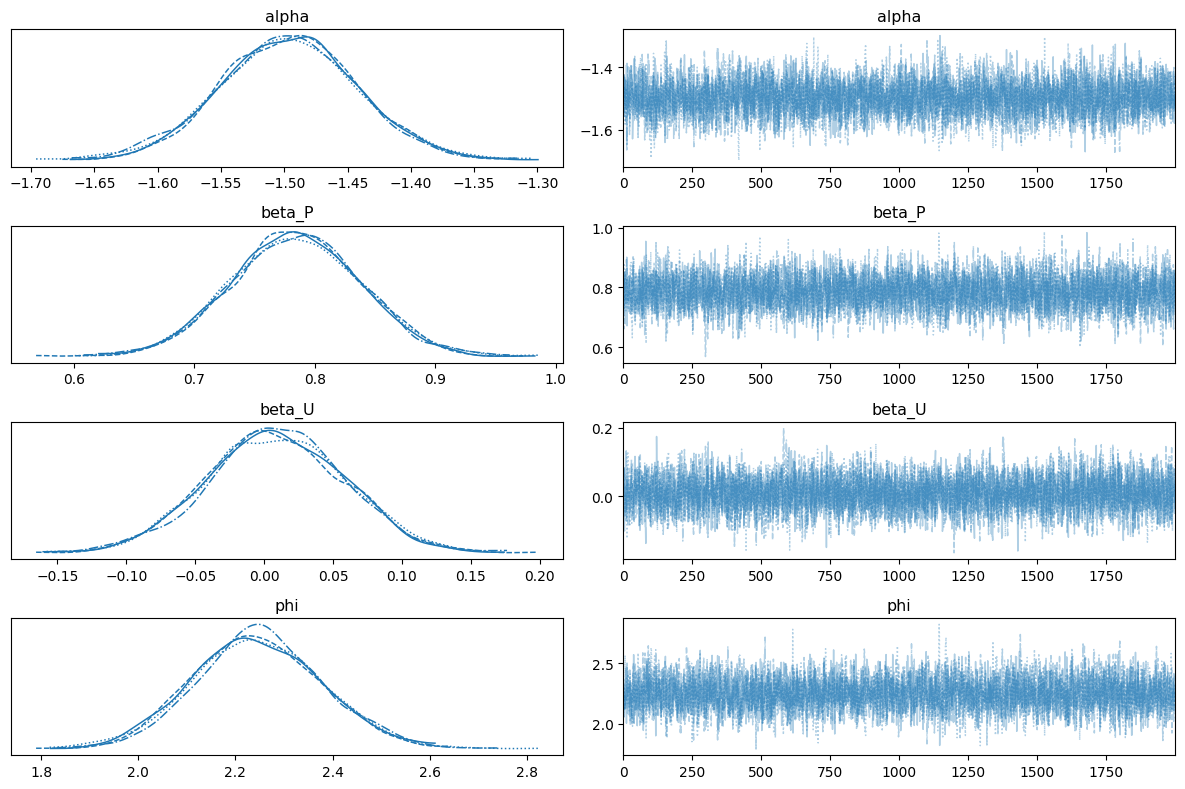

In [ ]:
summary = az.summary(idata_beta, var_names=["alpha", "beta_P", "beta_U", "phi"])
print(summary.round(3))

az.plot_trace(idata_beta, var_names=["alpha", "beta_P", "beta_U", "phi"])
plt.tight_layout()
plt.show()

**Diagnostics summary.** All parameters reach $\hat{R} = 1.00$ and `ess_bulk` is well above the rule-of-thumb minimum of 400. The trace plots show four well-mixed chains with no obvious drift, and Monte Carlo standard errors are small relative to posterior SDs. Zero divergences were reported during sampling. The posterior is reliably estimated.

## 7. Posterior Predictive Checks (full hurdle-passed set)

We visualize predictions for **every player the binomial passed** (~2,700 player-seasons). This includes the ~660 the Beta was trained on (binomial pass + got votes) and the ~2,080 false positives (binomial pass + no votes, observed share = 0).

The two plots include all four required PPC elements: observed data points, posterior mean, 89% HDI of the posterior mean, and 89% HDI of the posterior predictions including outcome noise.

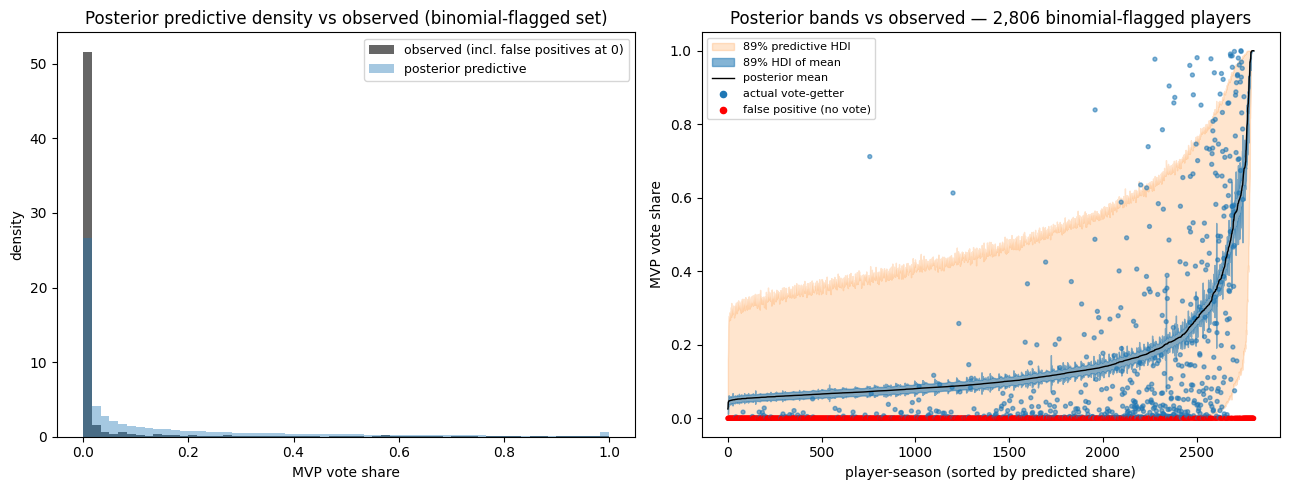

Evaluation set: 2,806 binomial-flagged player-seasons
  -- with actual votes (true positives, blue):  661
  -- without actual votes (false positives, red): 2,145


In [ ]:
# Build the evaluation set: all binomial-flagged players
df_eval = df_hurdle[df_hurdle["binom_pass"] == 1].copy().reset_index(drop=True)
df_eval["per_z"]         = (df_eval["per"]         - per_mean_t) / per_std_t
df_eval["usg_percent_z"] = (df_eval["usg_percent"] - usg_mean_t) / usg_std_t

# Posterior draws for slopes/intercept
alpha_draws = idata_beta.posterior["alpha"].stack(s=("chain", "draw")).values   # (S,)
betaP_draws = idata_beta.posterior["beta_P"].stack(s=("chain", "draw")).values
betaU_draws = idata_beta.posterior["beta_U"].stack(s=("chain", "draw")).values
phi_draws   = idata_beta.posterior["phi"].stack(s=("chain", "draw")).values

per_z_eval = df_eval["per_z"].values[:, None]   # (N, 1)
usg_z_eval = df_eval["usg_percent_z"].values[:, None]
eta = alpha_draws[None, :] + betaP_draws[None, :] * per_z_eval + betaU_draws[None, :] * usg_z_eval
mu_eval = 1 / (1 + np.exp(-eta))   # (N, S)

# Posterior predictive y samples
rng_pp = np.random.default_rng(42)
y_pp = rng_pp.beta(mu_eval * phi_draws[None, :], (1 - mu_eval) * phi_draws[None, :])

mu_mean = mu_eval.mean(axis=1)
mu_hdi  = np.column_stack([np.quantile(mu_eval, 0.055, axis=1),
                            np.quantile(mu_eval, 0.945, axis=1)])
ppc_hdi = np.column_stack([np.quantile(y_pp, 0.055, axis=1),
                            np.quantile(y_pp, 0.945, axis=1)])

order = np.argsort(mu_mean)
x = np.arange(len(order))
y_obs_eval = df_eval["mvp_share"].values
got_vote_eval = df_eval["got_vote"].values

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Panel 1: marginal density (posterior predictive vs observed)
axes[0].hist(df_eval["mvp_share"], bins=60, density=True, alpha=0.6,
             color="black", label="observed (incl. false positives at 0)")
axes[0].hist(y_pp[:, ::20].flatten(), bins=60, density=True, alpha=0.4,
             color="C0", label="posterior predictive")
axes[0].set(title="Posterior predictive density vs observed (binomial-flagged set)",
            xlabel="MVP vote share", ylabel="density")
axes[0].legend(fontsize=9)

# Panel 2: per-observation bands
axes[1].fill_between(x, ppc_hdi[order, 0], ppc_hdi[order, 1],
                     alpha=0.20, color="C1", label="89% predictive HDI")
axes[1].fill_between(x, mu_hdi[order, 0], mu_hdi[order, 1],
                     alpha=0.55, color="C0", label="89% HDI of mean")
axes[1].plot(x, mu_mean[order], color="black", lw=1, label="posterior mean")
# Color observed dots: blue if got vote, red if false positive (binom pass + no vote)
colors = np.where(got_vote_eval[order] == 1, "C0", "red")
axes[1].scatter(x, y_obs_eval[order], s=8, c=colors, alpha=0.55)
axes[1].scatter([], [], c="C0", s=20, label="actual vote-getter")
axes[1].scatter([], [], c="red", s=20, label="false positive (no vote)")
axes[1].set(xlabel="player-season (sorted by predicted share)",
            ylabel="MVP vote share",
            title=f"Posterior bands vs observed — {len(df_eval):,} binomial-flagged players")
axes[1].legend(loc="upper left", fontsize=8)

plt.tight_layout()
plt.show()

print(f"Evaluation set: {len(df_eval):,} binomial-flagged player-seasons")
print(f"  -- with actual votes (true positives, blue):  {int(got_vote_eval.sum()):,}")
print(f"  -- without actual votes (false positives, red): {int((got_vote_eval == 0).sum()):,}")

**Discussion of fit (full hurdle-passed set).**

- **Marginal density (left panel):** observed shares (black) are dominated by zeros (false positives the binomial flagged but who actually got no votes). The posterior predictive density (blue) shows what the Beta predicts for these players' shares — it places mass near 0 because their PER and Usage put them low on the predicted-share spectrum. The pile of zeros in the observed series is the structural "false positive" signature of the binomial filter.
- **Per-observation bands (right panel):** sorted by predicted share. Blue dots are real vote-getters; red dots are false positives (observed share = 0). On the left, the predictive HDI starts very low (the model correctly predicts low share for low-PER/USG players), and false positives mostly fall inside the band. On the right, real vote-getters' shares climb with predicted share, generally tracking the band but with the same heavy-tail underprediction noted in Section 9 — extreme winners (Shaq, LeBron, KG) sit above the band.
- **Hurdle false negatives (not shown).** The ~70 actual vote-getters the binomial filtered out are excluded from this plot entirely; the combined pipeline predicts 0 for them. They are the "cost" of Design B — visible in the recall figure from Section 5b.

Together, the plots show the model is doing what we asked: PER and Usage place each candidate on a predicted-share spectrum, with the Beta posterior expressing genuine uncertainty about magnitude, and false positives systematically pushed toward zero. The remaining errors trace to the same missing variables (team success, narrative) we have flagged throughout.

## 7b. Combined two-stage prediction over the full population

For every player-season in the full dataset (~20,000), we apply the combined two-stage rule:

- if the binomial says "no votes" (probability < 0.5) → predicted share = 0
- otherwise → predicted share = Beta posterior mean

This is the prediction pipeline as it would be deployed to score arbitrary new players.

In [ ]:
# Compute Beta posterior mean for ALL players in df_hurdle, then gate by binom_pass
alpha_post = float(idata_beta.posterior["alpha"].mean(["chain", "draw"]).values)
betaP_post = float(idata_beta.posterior["beta_P"].mean(["chain", "draw"]).values)
betaU_post = float(idata_beta.posterior["beta_U"].mean(["chain", "draw"]).values)

per_z_full = (df_hurdle["per"]         - per_mean_t) / per_std_t
usg_z_full = (df_hurdle["usg_percent"] - usg_mean_t) / usg_std_t
beta_pred = 1 / (1 + np.exp(-(alpha_post + betaP_post * per_z_full + betaU_post * usg_z_full)))

df_hurdle["combined_pred"] = np.where(df_hurdle["binom_pass"] == 1, beta_pred, 0.0)

from sklearn.metrics import mean_absolute_error, mean_squared_error
mae  = mean_absolute_error(df_hurdle["mvp_share"], df_hurdle["combined_pred"])
rmse = np.sqrt(mean_squared_error(df_hurdle["mvp_share"], df_hurdle["combined_pred"]))

n_missed_voters = int(((df_hurdle["mvp_share"] > 0) & (df_hurdle["binom_pass"] == 0)).sum())
n_total_voters  = int((df_hurdle["mvp_share"] > 0).sum())

print(f"Combined pipeline diagnostics on full dataset (N = {len(df_hurdle):,}):")
print(f"  MAE:                                       {mae:.4f}")
print(f"  RMSE:                                      {rmse:.4f}")
print(f"  Vote-getters predicted 0 (hurdle losses):  {n_missed_voters}/{n_total_voters} ({100*n_missed_voters/n_total_voters:.1f}%)")

Combined pipeline diagnostics on full dataset (N = 20,547):
  MAE:                                       0.0186
  RMSE:                                      0.0728
  Vote-getters predicted 0 (hurdle losses):  70/731 (9.6%)


In [19]:
# Biggest misses of the combined two-stage model (across all ~20k player-seasons)
inspect = df_hurdle.assign(
    predicted=df_hurdle["combined_pred"],
    residual=df_hurdle["mvp_share"] - df_hurdle["combined_pred"],
)

print("Top UNDER-predictions (combined model said low/0, actual high — likely binomial false negatives):")
print(inspect.nlargest(10, "residual")[
    ["season", "player", "per", "usg_percent", "mvp_share", "binom_pass", "predicted", "residual"]
].round(3).to_string(index=False))

print()
print("Top OVER-predictions (combined model said high, actual low/0 — likely binomial false positives passed to Beta):")
print(inspect.nsmallest(10, "residual")[
    ["season", "player", "per", "usg_percent", "mvp_share", "binom_pass", "predicted", "residual"]
].round(3).to_string(index=False))


Top UNDER-predictions (combined model said low/0, actual high — likely binomial false negatives):
 season         player  per  usg_percent  mvp_share  binom_pass  predicted  residual
   2011   Derrick Rose 23.5         32.2      0.977           1      0.186     0.791
   1983   Moses Malone 25.1         26.0      0.960           1      0.249     0.711
   1986     Larry Bird 25.6         27.6      0.981           1      0.273     0.708
   2005     Steve Nash 22.0         20.5      0.839           1      0.135     0.704
   2001  Allen Iverson 24.0         35.9      0.904           1      0.206     0.698
   1998 Michael Jordan 25.2         33.7      0.934           1      0.256     0.678
   1985     Larry Bird 26.5         28.5      0.978           1      0.318     0.660
   2008    Kobe Bryant 24.2         31.4      0.873           1      0.213     0.660
   1984     Larry Bird 24.2         26.7      0.858           1      0.211     0.647
   2002     Jason Kidd 19.1         22.5      0.712 

## 8. Discussion and Conclusion

### 8.1. Answering the Question

**The posterior says PER has a substantial positive effect on MVP vote share, and Usage Rate retains a small negative effect after conditioning on PER — both consistent with the directions we encoded in our priors.**

**Interpreting $\beta_P$.** A 1 standard deviation bump in PER (≈ 3.8 PER points) increases the log-odds of expected MVP vote share by an average of 0.8. This translates to about a 2x increase in odds of vote share given a fixed usage rate.

**Causal-effect Conclusion.** The forest plot (next cell) shows the posterior 94% HDI for both $\beta_P$ and $\beta_U$. The HDI on $\beta_P$ is far from zero, strong evidence within the model and the assumed DAG that this advanced metric is a good predictor on MVP share when confounded by usage rate. This is supported by a tight, positive HDI on $\beta_P$, shown in the forest plot and a posterior predictive distribution closely matching observed data.

**Role of the Binomial Hurdle.** The binomial hurdle also improves the interpretation of the overall pipeline. MVP voting is a rare-event outcome because most player-seasons receive no MVP vote share at all. The first-stage binomial model handles this zero-heavy structure by estimating whether a player is likely to enter the MVP voting conversation. Conditional on passing that gate, the Beta regression then estimates the magnitude of positive vote share. This two-stage setup is more realistic than forcing one model to explain both vote receipt and positive vote-share magnitude.

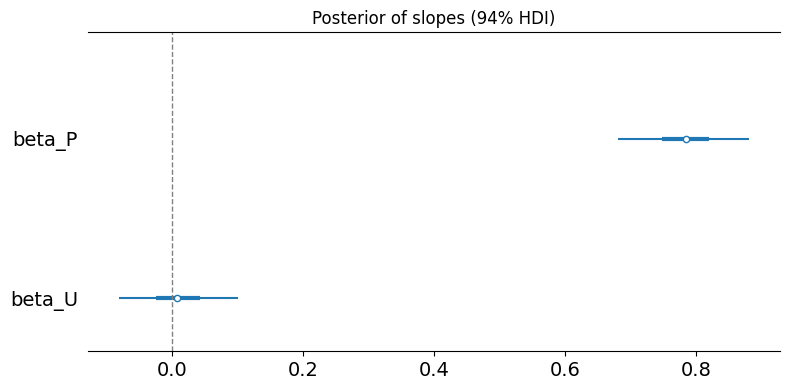

In [ ]:
# Posterior of the causal-effect estimate (beta_P) and the confounder slope (beta_U)
fig, ax = plt.subplots(figsize=(8, 4))
az.plot_forest(idata_beta, var_names=["beta_P", "beta_U"],
               hdi_prob=0.94, combined=True, ax=ax)
ax.axvline(0, color="grey", linestyle="--", linewidth=1)
ax.set_title("Posterior of slopes (94% HDI)")
plt.tight_layout()
plt.show()

### 8.2. Addressing the Confound

**Effect of the confound.** Based on a positive priors ($\beta_U \sim \mathcal{N}(0.3, 1)$) we expect a small positive Usage effect,  The posterior interval for $\beta_U$ tells us how much marginal information Usage carries above PER.

**Why the marginal Usage effect is small and negative.** PER rewards box-score volume. In a regression, much of what Usage would contribute to MVP share is already absorbed by PER itself (a player must have touches to put up high PER). Despite our assumption that usage is positively correlated with MVP, the model actually shows a negative beta once adjusted for PER. We suspect that this is the result of a correlation between team strength and mvp share. Poorly performing teams are less likely to have players with high MVP shares but are more likely to have players with higher usage rates.

## 9. Future Work

The current 3-variable analysis is informative within its scope but is bounded by both the project's variable budget and the assumptions of the chosen DAG. Findings from the model directly motivate concrete extensions.

**Limitations exposed by the analysis.**

1. **Residual variance is large.** The posterior predictive HDI is wide, reflecting unmodeled drivers, narrative, voter fatigue (voters' reluctance to vote for repeat MVPs), team success, that PER and Usage cannot capture.
2. **Heavy-tail underprediction.** The model under-fits 0.99-share winners (Shaq 2000, LeBron 2013, KG 2004). These extreme MVP runs typically combine top-tier individual stats and team success, and the model has access only to the former.
3. **High false positive rate.** When using a gated model, the amount of false positives skyrocket. Some players who the model predicts should have a high MVP share actually have zero MVP share

**Variables to add next.**

- **Team win percentage.** Probably the largest single MVP predictor not in the current model. The Westbrook-2017-vs-Harden-2018 contrast suggests team success can override individual efficiency in voter preference.
- **Per-season fixed effects.** PER inflation has shifted across decades; a hierarchical season intercept would absorb era effects without consuming a "variable" in the causal sense.
- **Points-per-game/Games played.** Players who receive low time in game/low games played may have an extremely high PER that might not accurately represent their efficiency as a player.

**Other questions worth exploring:**

- Does the PER → MVP relationship change across eras?
- How does minutes played per game affect their MVP share?

## 10. Group Member Contributions

* **Proposal:** Andy Cho, Tyler Song
* **Introduction:** Tyler Song
* **Causal Model:** Andy Cho, Satya Dasari
* **Statistical Model:** Tyler Song, Andy Cho, Satya Dasari
* **Model Validation on Simulated Data:** Andy Cho
* **Data Preparation:** Tyler Song, Satya Dasari
* **Posterior Model (Analysis on Real Data):** Tyler Song, Andy Cho, Satya Dasari
* **Posterior Predictive Checks:** Andy Cho, Satya Dasari
* **Discussion and Conclusion:** Tyler Song, Andy Cho, Satya Dasari
* **Future Work:** Andy Cho